# Diagnosing Haar features

In the following, we'll take a deeper look at what the model sees when computing a Haar feature. We'll both get more comfortable with what an integral image is and also how it's employed to produce fast computation of large image slices.

In [2]:
import os
import matplotlib.pyplot as plt
import numpy as np
import sys
from skimage import io
from skimage.color import rgb2gray
from skimage.util import img_as_ubyte
from loguru import logger
import cv2

logger.remove()
logger.add(sys.stderr, format="<level>{level}</level> | <level>{message}</level>")

1

### Loading and displaying the Haar images

We'll start by loading both the reference and a computed Haar stage image.

In [5]:
# Load both the stage image and the reference image
feat_dir = 'haar_features'
img_path = os.path.join(feat_dir, 'stage_3.png')
stage_img = io.imread(img_path)
ref_path = 'annotation_img.jpg'
ref_img = io.imread(ref_path)
ref_img = img_as_ubyte(rgb2gray(ref_img)) # Want the image to be grayscaled

# Look at the stage image shape
logger.info(stage_img.shape)

INFO | (240, 1200)


We find, that the images have been upscaled by x10 (240x1200) // 10 -> (24x24x5). Slicing according to our chosen feature and resizing, we get:

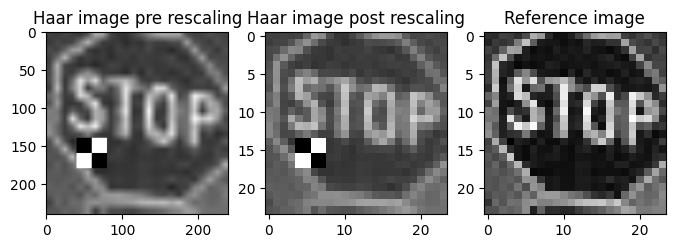

In [6]:
# Rescale image down to w_window x h_window
w_enlargened, h_enlargened = (stage_img.shape[0],stage_img.shape[0])
ROI_feat = 2
ROI_img = stage_img[:, ROI_feat*w_enlargened:(ROI_feat+1)*w_enlargened]
resized_img = cv2.resize(ROI_img, (w_enlargened//10,h_enlargened//10), interpolation = cv2.INTER_AREA)

_, axes = plt.subplots(ncols=3, figsize=(8,8))

axes[0].imshow(ROI_img, cmap='gray')
axes[0].set_title('Haar image pre rescaling')
axes[1].imshow(resized_img, cmap='gray')
axes[1].set_title('Haar image post rescaling')
axes[2].imshow(ref_img, cmap='gray')
axes[2].set_title('Reference image')
plt.show()

### Identify ROI pixels

We now want to zoom in to the region of interest. Looking at the image histogram for the resized image, this gives us some hints.

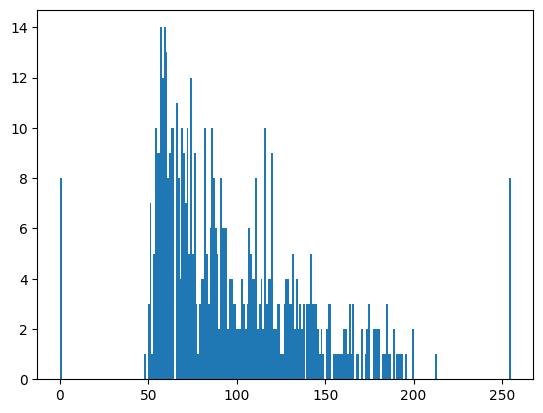

In [7]:
plt.hist(resized_img.ravel(), bins=256)
plt.show()

Two very clear spikes form at 0 and 255, which incidentally are also the pixels we'd like to mask.

INFO | (2, 16)


(array([14,  4]), array([17,  7]))


/tmp/ipykernel_559658/2734021977.py:10: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(resized_img[ymin-1:ymax+2,xmin-1:xmax+2])


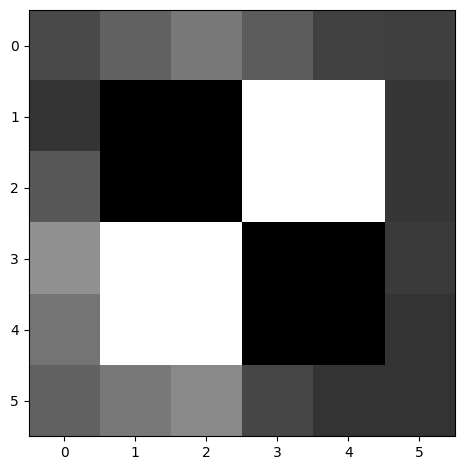

In [ ]:

# Retrieve all pixels with boundary values
ys, xs = np.where((resized_img == 0) | (resized_img == 255))
coords = np.vstack((ys, xs)) # ys,xs due to standard convention of packages

# Get (y0,x0) and (y1,x1), slice and show image
ymin, xmin, ymax, xmax = np.concatenate((coords.min(axis=1), coords.max(axis=1)))
io.imshow(resized_img[ymin-1:ymax+2,xmin-1:xmax+2])
plt.show()

Notice, we choose to append an extra border layer, in order to effectively compute the Haar feature, as it depends on values outside of the bounding box. This is only relevant if we choose to use *np.cumsum* - if you use *cv2.integral* the border is zero padded.

### Compute integral image

Now we compute the integral image using *np.cumsum*. We then visualize 

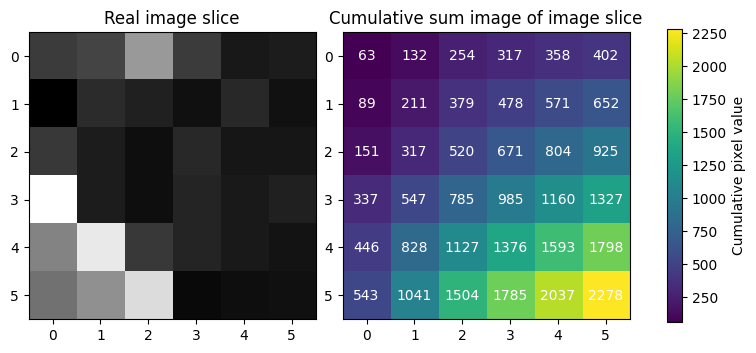

In [ ]:

# Retrieve sliced image
sliced_img = ref_img[ymin-1:ymax+2,xmin-1:xmax+2]
# sliced_img = ref_img[ymin:ymax+1,xmin:xmax+1]

# Integral image options
# integral_img = cv2.integral(sliced_img)[1:,1:] # Padds boundary - hence we may remove the first row of y,x respectfully
# integral_img = np.cumsum(np.cumsum(sliced_img, axis=0), axis=1)

# Visualize the sliced image along with its integral counterpart
fig, axes = plt.subplots(ncols=2, figsize=(8,8))
axes[0].imshow(sliced_img, cmap='gray')
axes[0].set_title('Real image slice')
axes[0].set_aspect('equal')
img = axes[1].imshow(integral_img, cmap='viridis')
axes[1].set_title('Cumulative sum image of image slice')
axes[1].set_aspect('equal')

# Write numbers on each pixel of cumsum image to gain extra insights
for (i, j), val in np.ndenumerate(integral_img):
    axes[1].text(j, i, f"{val}", ha='center', va='center', color='white', fontsize=10)

plt.tight_layout()
fig.colorbar(img, label='Cumulative pixel value', ax=axes, shrink=0.38)
plt.show()

### Compute Haar feature

We're now ready to compute our Haar feature. We first need to separate Haar regions accordingly. In our case, we're working with a four rectangle diagonal Haar feature, whose starting positions (top left corner) can be found as below:

In [39]:

# Retrieve w, h of the Haar regions
w, h = integral_img.shape[1], integral_img.shape[0]
w_reg, h_reg = w//2, h//2

# As regions are standard uniform, we may retrieve start positions of each region like:
start_positions = np.array([
    [(y, x) for x in np.linspace(start=1, stop=w_reg, num=2)]
    for y in np.linspace(start=1, stop=h_reg, num=2)]
).reshape(-1, 2)

logger.info(start_positions)

INFO | [[1. 1.]
 [1. 3.]
 [3. 1.]
 [3. 3.]]


Now, we'll add some functions, that will help locate the corners of each Haar region, compute their individual summed area and finally compute the 4 region Haar feature.

In [31]:
def compute_integral_image(integral_img, y0, x0, w, h):
    """
        Computes the integral image within the bounding box represented by (y0,x0,w,h).

        :param numpy.ndarray integral_img:      The integral image input. Dimensions need to supercede those of the bounding box.
        :param int y0:                          Initial starting y position of bounding box.
        :param int x0:                          Initial starting x position of bounding box.
        :param int w:                           Width of bounding box.
        :param int h:                           Height of bounding box.
    """
    
    # Retrieve corners of bounding box
    pos1, pos2, pos3, pos4 = (y0-1, x0-1), (y0-1, x0-1+w-1),(y0-1+h-1, x0-1), (y0-1+h-1, x0-1+w-1)

    # Compute integral image
    A = integral_img[pos1[0], pos1[1]]
    B = integral_img[pos2[0], pos2[1]]
    C = integral_img[pos3[0], pos3[1]]
    D = integral_img[pos4[0], pos4[1]]
    return D + A - B - C

def compute_diagonal_feat(integral_img, start_positions, w_reg, h_reg):
    """
        Computes the diagonal Haar feature of a 
    """

    # Compute integral image for each square region
    regions = []
    for y,x in start_positions:
        reg_integral = compute_integral_image(integral_img, int(y), int(x), w_reg, h_reg)
        regions.append(reg_integral)
   
    # Compute Haar feature
    white_pixels = regions[1] + regions[2]
    black_pixels = regions[0] + regions[3]
    haar_feat =  white_pixels - black_pixels

    return haar_feat


Using the function, we can compute the value of the Haar feature.

In [40]:
haar_feat = compute_diagonal_feat(integral_img, start_positions, w_reg, h_reg)
logger.info(f"The computed Haar feature of image slice = {haar_feat}")

INFO | The computed Haar feature of image slice = 132
